Import Libraries

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Import Data

In [31]:
df = pd.read_csv('students_performance.csv')

In [12]:
df.head(5)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [16]:
df.shape

(1000, 8)

Find NA values

In [24]:
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

For a particular course, the total marks is 100. So let's set passmark has 35 marks.

In [35]:
passmark = 35

Let's create three new columns: Percentage and grade

In [48]:
df['percentage']= (df['math score'] + df['reading score'] + df['writing score']) / 3

Developing grading system

In [56]:
def grade(percentage):
    if (percentage >= 95) : return 'O'
    if (percentage >= 81) : return 'A'
    if (percentage >= 71) : return 'B'
    if (percentage >= 61) : return 'C'
    if (percentage >= 51) : return 'D'
    if (percentage >= 41) : return 'E'
    else : return 'F'

df['grade']= df.apply(lambda x : grade(x['percentage']), axis= 1)

In [113]:
df.head(15)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,percentage,grade
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667,B
1,female,group C,some college,standard,completed,69,90,88,82.333333,A
2,female,group B,master's degree,standard,none,90,95,93,92.666667,A
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333,E
4,male,group C,some college,standard,none,76,78,75,76.333333,B
5,female,group B,associate's degree,standard,none,71,83,78,77.333333,B
6,female,group B,some college,standard,completed,88,95,92,91.666667,A
7,male,group B,some college,free/reduced,none,40,43,39,40.666667,F
8,male,group D,high school,free/reduced,completed,64,64,67,65.000000,C
9,female,group B,high school,free/reduced,none,38,60,50,49.333333,E


In [60]:
df.describe()

,math score,reading score,writing score,percentage
count,1000.00000,1000.000000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000,67.770667
std,15.16308,14.600192,15.195657,14.257326
min,0.00000,17.000000,10.000000,9.000000
25%,57.00000,59.000000,57.750000,58.333333
50%,66.00000,70.000000,69.000000,68.333333
75%,77.00000,79.000000,79.000000,77.666667
max,100.00000,100.000000,100.000000,100.000000


In [62]:
sns.set(style= 'whitegrid')

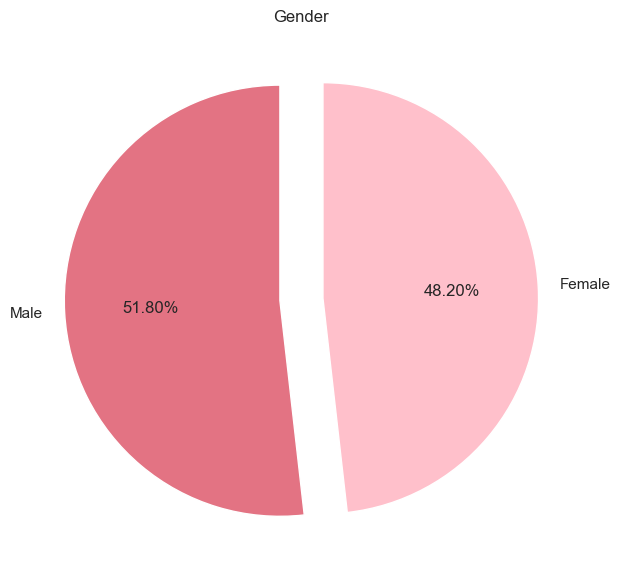

In [88]:
plt.figure(figsize= (14,7))
plt.pie(df['gender'].value_counts(),labels= ['Male', 'Female'],explode= [0.1, 0.1], autopct= '%1.2f%%', colors=['#E37383','#FFC0CB'], startangle=90)
plt.title('Gender')
plt.show()

Out of the total number of students, 51.89% are females while 48.20% are males.

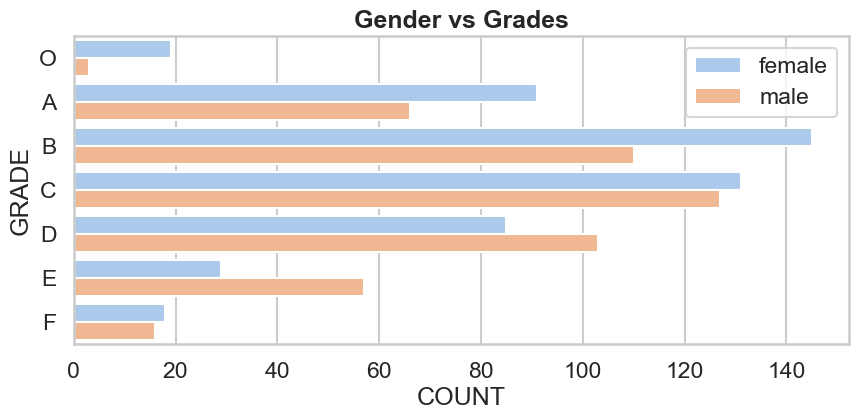

In [109]:
plt.figure(figsize= (10, 4))
sns.set_context('talk', font_scale= 1)
sns.set_palette('pastel')
ax= sns.countplot(y= 'grade', hue= 'gender', data= df, order= ['O', 'A', 'B', 'C', 'D', 'E', 'F'])
ax.legend()
plt.title('Gender vs Grades', fontsize= 18, fontweight= 'bold')
ax.set(xlabel='COUNT',ylabel='GRADE')
plt.show()

C:\Users\avdho\AppData\Local\Temp\ipykernel_19812\2195458485.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df,shade = True)


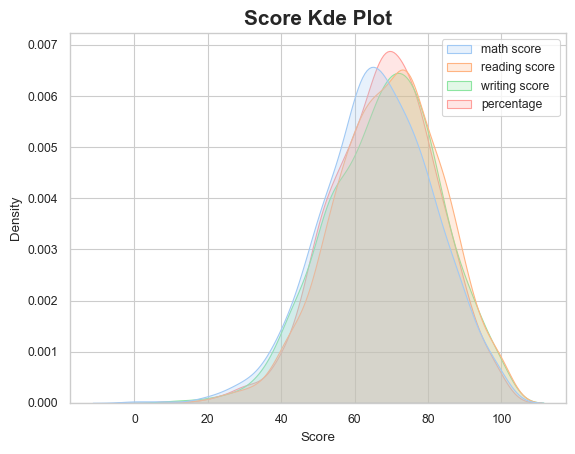

In [111]:
sns.set_context("paper",font_scale=1)
sns.kdeplot(data=df,shade = True)
plt.xlabel('Score')
plt.title('Score Kde Plot', fontsize=15, fontweight='bold')
plt.show()

<Axes: xlabel='parental level of education'>

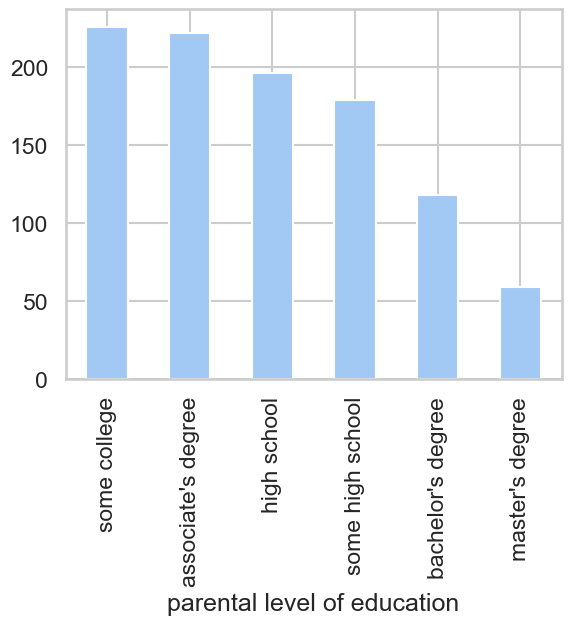

In [125]:
parental_edu= df['parental level of education'].value_counts()
parental_edu.plot(kind= 'bar')

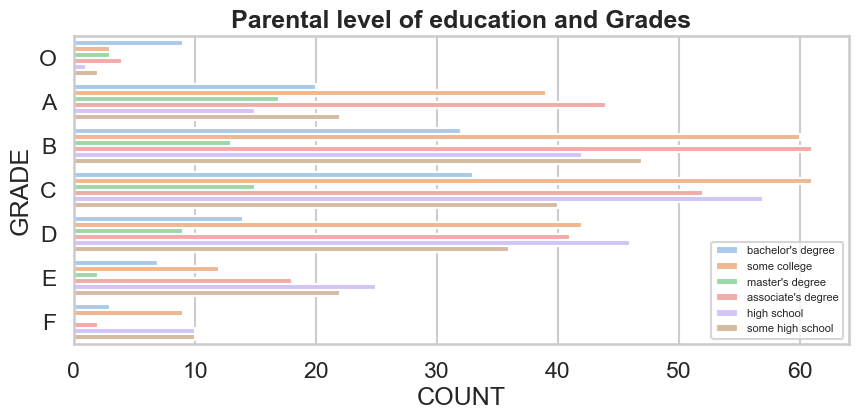

In [129]:
plt.figure(figsize= (10, 4))
sns.set_context('talk', font_scale= 1)
sns.set_palette('pastel')
ax= sns.countplot(y= 'grade', hue= 'parental level of education', data= df, order= ['O', 'A', 'B', 'C', 'D', 'E', 'F'])
ax.legend(fontsize=8)
plt.title('Parental level of education and Grades', fontsize= 18, fontweight= 'bold')
ax.set(xlabel='COUNT',ylabel='GRADE')
plt.show()

In [215]:
percentage_scores = df.groupby('parental level of education')['percentage'].apply(list).to_dict()

C:\Users\avdho\AppData\Local\Temp\ipykernel_19812\3164451749.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  percentage_scores = df.groupby('parental level of education')['percentage'].apply(list).to_dict()


In [219]:
percentage_scores_df = pd.DataFrame.from_dict(percentage_scores, orient='index').transpose()
display(percentage_scores_df)

,master's degree,bachelor's degree,associate's degree,some college,some high school,high school
0,92.666667,72.666667,49.333333,82.333333,74.000000,65.000000
1,53.666667,75.000000,77.333333,76.333333,26.000000,49.333333
2,44.666667,70.333333,54.666667,91.666667,71.666667,73.000000
3,73.000000,75.000000,45.000000,40.666667,57.666667,87.666667
4,69.000000,79.666667,57.666667,73.333333,80.666667,66.000000
...,...,...,...,...,...,...
221,NaN,NaN,69.000000,60.666667,NaN,NaN
222,NaN,NaN,NaN,85.333333,NaN,NaN
223,NaN,NaN,NaN,78.666667,NaN,NaN
224,NaN,NaN,NaN,74.333333,NaN,NaN


In [221]:
average_scores = pd.DataFrame(percentage_scores_df.mean())
display(average_scores)

,0
master's degree,73.598870
bachelor's degree,71.923729
associate's degree,69.569069
some college,68.476401
some high school,65.108007
high school,63.096939


Text(0, 0.5, 'Percentage')

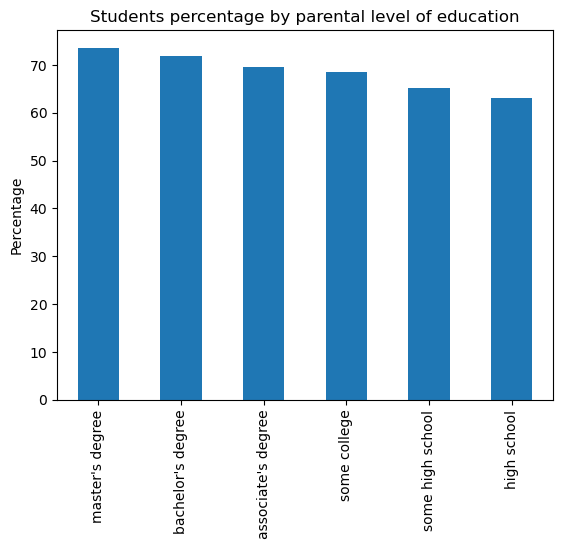

In [223]:
average_scores.plot(kind= 'bar')
plt.legend().remove()
plt.title('Students percentage by parental level of education')
plt.ylabel('Percentage')

Parents who are highly educated resulting higher percentage in their childrens educational score.

In [207]:
completed_test_prep_by_grade= df[df['test preparation course']== 'completed']['grade'].value_counts()

Text(0, 0.5, 'Completed Counts')

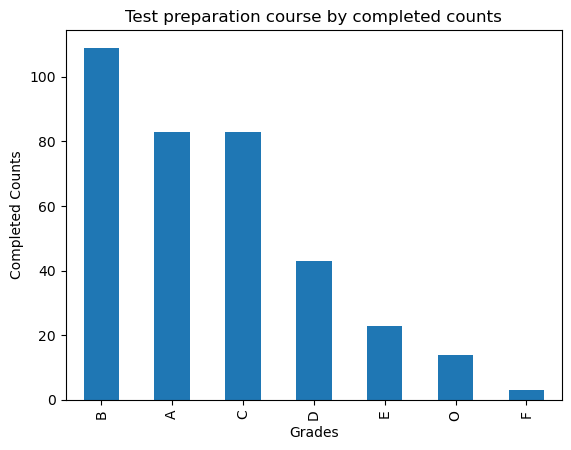

In [211]:
completed_test_prep_by_grade.plot(kind= 'bar')
plt.legend().remove()
plt.title('Test preparation course by completed counts')
plt.xlabel('Grades')
plt.ylabel('Completed Counts')

Students who are completed their preparation testing resulting better grades.

In [259]:
df['lunch'].unique()

array(['standard', 'free/reduced'], dtype=object)

In [263]:
standard_lunch_by_grade= df[df['lunch']== 'standard']['grade'].value_counts()

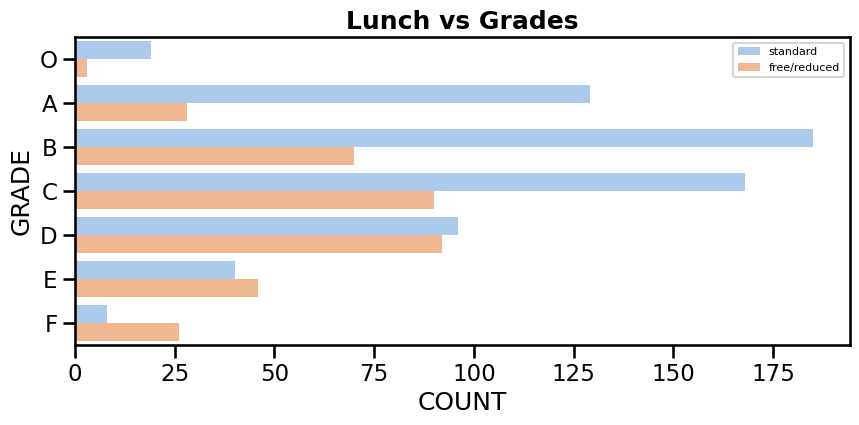

In [275]:
plt.figure(figsize= (10, 4))
sns.set_context('talk', font_scale= 1)
sns.set_palette('pastel')
ax= sns.countplot(y= 'grade', hue= 'lunch', data= df, order= ['O', 'A', 'B', 'C', 'D', 'E', 'F'])
ax.legend(fontsize=8)
plt.title('Lunch vs Grades', fontsize= 18, fontweight= 'bold')
ax.set(xlabel='COUNT',ylabel='GRADE')
plt.show()

Students who are consuming standard lunch resulting better grades.